<a href="https://colab.research.google.com/github/Ziqi-Li/GIS5106/blob/main/notebooks/W07%20Image_Object_Recognition_with_Yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Image Object Recognition

Yolo is a state-of-art real-time object detection and image segmentation model/package.



https://github.com/ultralytics/ultralytics


Here is a small example on using YOLO to detect and count how many cars in an image.

In [ ]:
pip install -q ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

VEHICLE_LABELS = {"car", "truck", "bus", "motorcycle"}

def detect_vehicles_notebook(image_path, conf=0.25, iou=0.5, imgsz=1280, model_name="yolov8n.pt"):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    model = YOLO(model_name)

    result = model.predict(
        source=str(image_path),
        conf=conf,
        iou=iou,
        imgsz=imgsz,
        verbose=False
    )[0]

    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise RuntimeError("OpenCV failed to read the image.")

    names = model.names
    vehicle_boxes = []

    for b in result.boxes:
        cls_id = int(b.cls[0].item())
        label = names[cls_id]
        score = float(b.conf[0].item())
        if label in VEHICLE_LABELS:
            x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
            vehicle_boxes.append((x1, y1, x2, y2, label, score))

    # draw
    for (x1, y1, x2, y2, label, score) in vehicle_boxes:
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_bgr, f"{label} {score:.2f}", (x1, max(y1-8, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # save annotated image
    out_path = image_path.with_suffix("").as_posix() + "_cars_annotated.jpg"
    cv2.imwrite(out_path, img_bgr)

    # show inline (convert BGR -> RGB for matplotlib)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Detected vehicles: {len(vehicle_boxes)}")
    plt.show()

    return vehicle_boxes, out_path

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


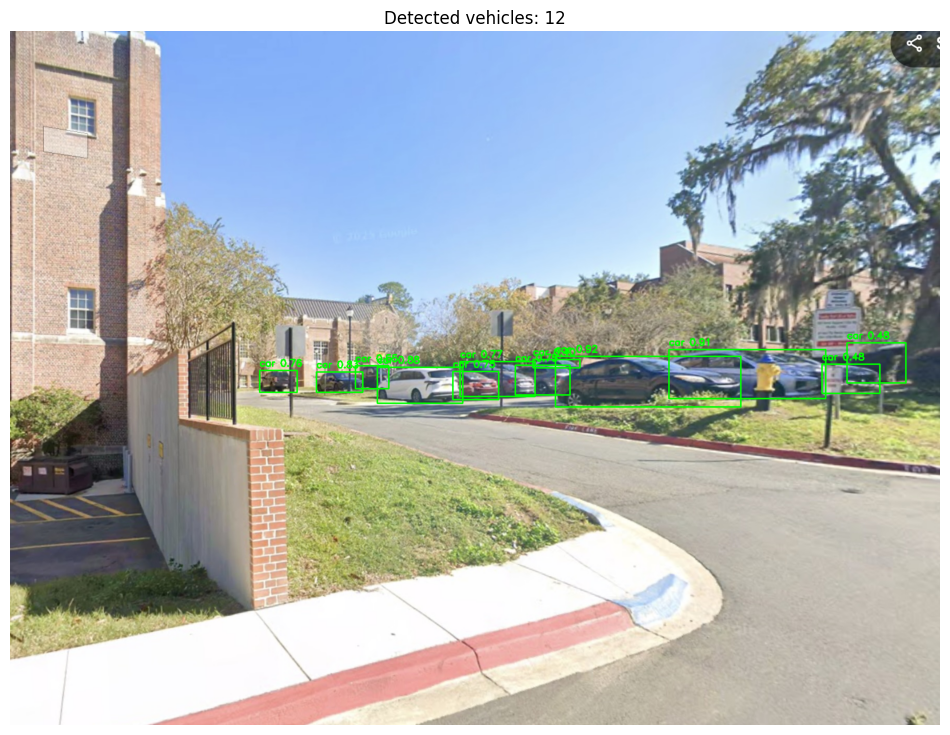

Saved: /content/car_cars_annotated.jpg
Count: 12


In [ ]:
# Example:
img = "/content/car.jpg"


boxes, out_path = detect_vehicles_notebook(img, imgsz=1600, conf=0.2, model_name="yolov8s.pt")

print("Saved:", out_path)
print("Count:", len(boxes))